## Medicine Dataset — Data Analysis Project

This dataset contains 248,218 medicine records including drug names,
therapeutic classes, side effects, substitutes, and habit-forming status.

**Goal:** explore which drug categories are most common, what side effects
appear most frequently, and whether drugs with substitutes are safer.

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r"C:\Users\salma\Documents\collage\datanalytic_sub\before_clean_medicine_dataset.csv",low_memory=False)
df

,id,name,substitute0,substitute1,substitute2,substitute3,substitute4,sideEffect0,sideEffect1,sideEffect2,sideEffect3,use0,use1,use2,use3,use4,Chemical Class,Habit Forming,Therapeutic Class,Action Class
0,1,augmentin 625 duo tablet,Penciclav 500 mg/125 mg Tablet,Moxikind-CV 625 Tablet,Moxiforce-CV 625 Tablet,Fightox 625 Tablet,Novamox CV 625mg Tablet,Vomiting,Nausea,Diarrhea,NaN,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,NaN,No,ANTI INFECTIVES,NaN
1,2,azithral 500 tablet,Zithrocare 500mg Tablet,Azax 500 Tablet,Zady 500 Tablet,Cazithro 500mg Tablet,Trulimax 500mg Tablet,Vomiting,Nausea,Abdominal pain,Diarrhea,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,Macrolides,No,ANTI INFECTIVES,Macrolides
2,3,ascoril ls syrup,Solvin LS Syrup,Ambrodil-LX Syrup,Zerotuss XP Syrup,Capex LS Syrup,Broxum LS Syrup,Nausea,Vomiting,Diarrhea,Upset stomach,Treatment of Cough with mucus,NaN,NaN,NaN,NaN,NaN,No,RESPIRATORY,NaN
3,4,allegra 120mg tablet,Lcfex Tablet,Etofex 120mg Tablet,Nexofex 120mg Tablet,Fexise 120mg Tablet,Histafree 120 Tablet,Headache,Drowsiness,Dizziness,Nausea,Treatment of Sneezing and runny nose due to al...,Treatment of Allergic conditions,NaN,NaN,NaN,Diphenylmethane Derivative,No,RESPIRATORY,H1 Antihistaminics (second Generation)
4,5,avil 25 tablet,Eralet 25mg Tablet,NaN,NaN,NaN,NaN,Sleepiness,Dryness in mouth,NaN,NaN,Treatment of Allergic conditions,NaN,NaN,NaN,NaN,Pyridines Derivatives,No,RESPIRATORY,H1 Antihistaminics (First Generation)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248213,248214,zestrain 100mg/325mg/250mg tablet mr,Aclotec MR 100mg/325mg/250mg Tablet,SAMONEC MR TABLET,Uniclof 100mg/325mg/250mg Tablet MR,Macito 100mg/325mg/250mg Tablet MR,Rumatin 100mg/325mg/250mg Tablet MR,Nausea,Vomiting,Heartburn,Stomach pain,Treatment of Muscular pain,NaN,NaN,NaN,NaN,NaN,No,PAIN ANALGESICS,NaN
248214,248215,zoxinace 200mg tablet sr,Algic 200mg Tablet SR,Topnac 200mg Tablet SR,Kindac 200mg Tablet SR,Ultranac 200mg Tablet SR,Bignac 200mg Tablet SR,Dizziness,Indigestion,Nausea,Abdominal pain,Pain relief,NaN,NaN,NaN,NaN,Dichlorobenzenes Derivative,No,PAIN ANALGESICS,NSAID's- Non-Selective COX 1&2 Inhibitors (ace...
248215,248216,zivex 25mg tablet,HD Zine 25mg Tablet,Hydrocas 25mg Tablet,Hyzox 25 Tablet,Hydil 25mg Tablet,Zyzine 25mg Tablet,Sedation,Nausea,Vomiting,Upset stomach,Treatment of Anxiety,Treatment of Skin conditions with inflammation...,NaN,NaN,NaN,Piperazine Derivative,No,RESPIRATORY,H1 Antihistaminics (First Generation)
248216,248217,zi fast 500mg injection,Zycin 500mg Injection,Aziwok 500mg Injection,Azirow 500mg Injection,Toracin 500mg Injection,Azymed 500mg Injection,"Injection site reactions (pain, swelling, redn...",Vomiting,Nausea,Abdominal pain,Treatment of Bacterial infections,NaN,NaN,NaN,NaN,Macrolides,No,ANTI INFECTIVES,Macrolides


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248218 entries, 0 to 248217
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   id                 248218 non-null  int64 
 1   name               248218 non-null  object
 2   substitute0        238621 non-null  object
 3   substitute1        233867 non-null  object
 4   substitute2        230233 non-null  object
 5   substitute3        226856 non-null  object
 6   substitute4        223962 non-null  object
 7   sideEffect0        248218 non-null  object
 8   sideEffect1        238416 non-null  object
 9   sideEffect2        229500 non-null  object
 10  sideEffect3        207638 non-null  object
 11  use0               248218 non-null  object
 12  use1               73365 non-null   object
 13  use2               28307 non-null   object
 14  use3               7379 non-null    object
 15  use4               4971 non-null    object
 16  Chemical Class     1

all data have nulls exibt 
 0   id                 248218 non-null  int64 
 1   name               248218 non-null  object
 7   sideEffect0        248218 non-null  object
 11  use0               248218 non-null  object
 17  Habit Forming      248218 non-null  object
 20  Use2_new           248218 non-null  object
 21  Use                248218 non-null  object

In [103]:
str_cols = df.select_dtypes(include="object").columns.tolist()
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())
print(df.isnull().sum()[df.isnull().sum() > 0])

substitute0            9597
substitute1           14351
substitute2           17985
substitute3           21362
substitute4           24256
sideEffect1            9802
sideEffect2           18718
sideEffect3           40580
use1                 174853
use2                 219911
use3                 240839
use4                 243247
Chemical Class       110427
Therapeutic Class        69
Action Class         110182
dtype: int64


In [105]:
print("\nuse0 value counts")
print(df['use0'].value_counts().head(10))
print("\nuse4 value counts")
print(df['use4'].value_counts().head(10))


use0 value counts
use0
Treatment of Bacterial infections                             39573
Pain relief                                                   22783
Treatment of Type 2 diabetes mellitus                         11350
Bacterial infections                                          11288
Treatment of Gastroesophageal reflux disease (Acid reflux)     9749
Treatment of Hypertension (high blood pressure)                7632
Treatment of Sneezing and runny nose due to allergies          5104
Treatment of Heartburn                                         4079
Treatment of Neuropathic pain                                  4050
Treatment of Allergic conditions                               3878
Name: count, dtype: int64

use4 value counts
use4
Treatment of Skin disorders                     1368
Prevention of Migraine                          1114
Head injury                                      479
Treatment of Neuropathic pain                    348
Treatment of Premenstrual dysphori

 Treatment of name , samename

In [72]:
use_cols = ["use0", "use1", "use2", "use3", "use4"]
 
for col in use_cols:
    # Step 1: check if value starts with "Treatment of " (case-insensitive)
    starts_with_treatment = df[col].str.lower().str.startswith("treatment of ")
 
    # Step 2: use np.where — if it starts with prefix → strip it, else keep original
    df[col] = np.where(
        starts_with_treatment,                         # condition
        df[col].str[len("treatment of "):].str.strip(),  # remove prefix
        df[col]                                        # keep as-is
    )

In [73]:
df["habit_forming"] = df["Habit Forming"].map({"Yes": True, "No": False})
df.drop(columns=["Habit Forming"], inplace=True)

In [74]:
df["Therapeutic_Class"] = df["Therapeutic Class"].str.title()
df.drop(columns=["Therapeutic Class"], inplace=True) 

In [75]:
df['Use2_new'] = df[['use1', 'use2', 'use3', 'use4']].fillna('').agg(
    lambda x: ' '.join(v for v in x if v != ''), axis=1)

In [76]:
df['Use']=df[['use0','Use2_new']].astype(str).agg(' '.join,axis=1) # tjme3 kol el use fe column wa7ed

In [77]:
df['Use'] = df['Use'].str.lower().str.strip().str.replace(r'\s+', ' ', regex=True)

In [78]:
df['substitutes'] = df[['substitute0', 'substitute1', 'substitute2',
                          'substitute3', 'substitute4']].apply(
    lambda x: ', '.join(v for v in x if pd.notna(v)), axis=1)
#Data['side_effects']= Data[['side_effect0','side_effect1','side_effect2','side_effect3',]].fillna('').agg(' '.join,axis=1)
#tjme3 kol el substitutes fe column 

In [79]:
df['side_effects'] = df[['sideEffect0', 'sideEffect1', 'sideEffect2',
                           'sideEffect3']].apply(lambda x: ', '.join(v for v in x if pd.notna(v)), axis=1)
#tjme3 kol el side effects fe column 

In [80]:
df['num_side_effects']=df[['sideEffect0','sideEffect1','sideEffect2','sideEffect3']].notnull().sum(axis=1)
df['hassubstitutes']=df[['substitute0','substitute1','substitute2','substitute3']].notnull().any(axis=1) # hl lee side effects

In [81]:
df = df.drop([
    'use0', 'use1', 'use2', 'use3', 'use4', 'Use2_new',
    'substitute0', 'substitute1', 'substitute2', 'substitute3', 'substitute4',
    'sideEffect0', 'sideEffect1', 'sideEffect2', 'sideEffect3',
    'Chemical Class', 'Action Class',
], axis=1)

In [82]:
df = df.drop(['id'], axis=1)
df.drop_duplicates(inplace=True)

In [83]:
print(df.isnull().sum())
print(df.shape)

name                  0
habit_forming         0
Therapeutic_Class    63
Use                   0
substitutes           0
side_effects          0
num_side_effects      0
hassubstitutes        0
dtype: int64
(224013, 8)


In [84]:
df['Therapeutic_Class'] = df['Therapeutic_Class'].fillna('Unknown')

In [85]:
df.isnull().sum()

name                 0
habit_forming        0
Therapeutic_Class    0
Use                  0
substitutes          0
side_effects         0
num_side_effects     0
hassubstitutes       0
dtype: int64

In [86]:
df.describe()

,num_side_effects
count,224013.000000
mean,3.720543
std,0.717010
min,1.000000
25%,4.000000
50%,4.000000
75%,4.000000
max,4.000000


Top 10 common drug names

In [87]:
print(df['name'].value_counts().head(10))

name
cefpoxim dry syrup         4
ringer lactate infusion    4
azim suspension            3
broxine syrup              3
cts syrup                  3
itratuf sb capsule         3
cepo tablet                3
cefxi o tablet dt          3
homatropine eye drop       3
artee 150mg injection      3
Name: count, dtype: int64


most common side effect 

In [88]:
print(df['side_effects'].value_counts().head(10))

side_effects
Vomiting, Nausea, Abdominal pain, Diarrhea                            4470
Vomiting, Nausea, Diarrhea                                            4014
Diarrhea, Stomach pain, Dryness in mouth, Headache                    3362
Nausea, Vomiting, Heartburn, Stomach pain                             3138
Nausea, Vomiting, Stomach pain, Indigestion                           3024
Diarrhea, Flatulence, Headache, Nausea                                2917
Nausea, Stomach pain, Indigestion, Diarrhea                           2805
Diarrhea, Stomach pain, Flatulence, Dryness in mouth                  2687
Hypoglycemia (low blood glucose level), Headache, Nausea, Diarrhea    2651
Rash, Nausea, Diarrhea                                                2552
Name: count, dtype: int64


In [89]:
df['habit_forming'].value_counts() # fi 5461 dwaa usbb edman *_*

habit_forming
False    218552
True       5461
Name: count, dtype: int64

In [90]:
df.groupby('Therapeutic_Class')['num_side_effects'].mean()

Therapeutic_Class
Anti Diabetic                  3.969685
Anti Infectives                3.730172
Anti Malarials                 3.961801
Anti Neoplastics               3.990631
Blood Related                  3.296266
Cardiac                        3.911291
Derma                          2.968265
Gastro Intestinal              3.867420
Gynaecological                 3.090132
Hormones                       3.980110
Neuro Cns                      3.895558
Ophthal                        3.343691
Ophthal Otologicals            2.921053
Others                         3.594828
Otologicals                    2.569845
Pain Analgesics                3.730017
Respiratory                    3.807884
Sex Stimulants Rejuvenators    3.998534
Stomatologicals                1.487654
Unknown                        3.142857
Urology                        3.733721
Vaccines                       3.673203
Vitamins Minerals Nutrients    2.896268
Name: num_side_effects, dtype: float64

In [91]:
df.groupby('hassubstitutes')['num_side_effects'].mean() # hl eladweyaa elli leha bdeel akter aman wla la 

hassubstitutes
False    3.428798
True     3.732501
Name: num_side_effects, dtype: float64

In [92]:
df['hassubstitutes'] = df['hassubstitutes'].map({True: 'Has Substitutes', False: 'No Substitutes'})

#  البدائل ليها اعراض جانبية اكتر بنسبة.3الرقمين متقاربيين ودا يعني ان البدائل أمنة تقريبا بنفس جودة الاصلية

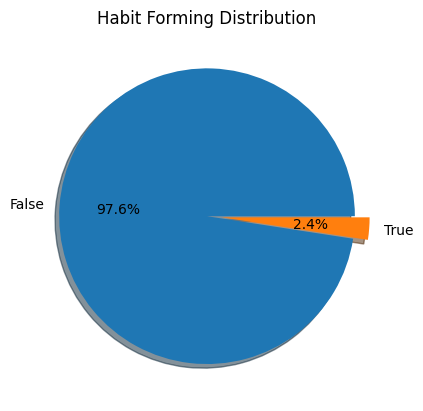

In [93]:
df['habit_forming'].value_counts().plot(
    kind='pie',
    shadow=True,
    autopct='%.1f%%',           # also fixed: was '1%.1f%%' → wrong format
    explode=(0.0, 0.1)
)
plt.title('Habit Forming Distribution')
plt.ylabel('')
plt.show()

In [94]:
raw = pd.read_csv(r"C:\Users\salma\Documents\collage\datanalytic_sub\new_medicine_dataset.csv")

therapeutic  = raw['Therapeutic Class'].value_counts().head(8)
side_effects = raw['sideEffect0'].value_counts().head(10)
habit        = df['habit_forming'].value_counts()        # ← df is fine here (boolean)
chemical     = raw['Chemical Class'].value_counts().head(6)

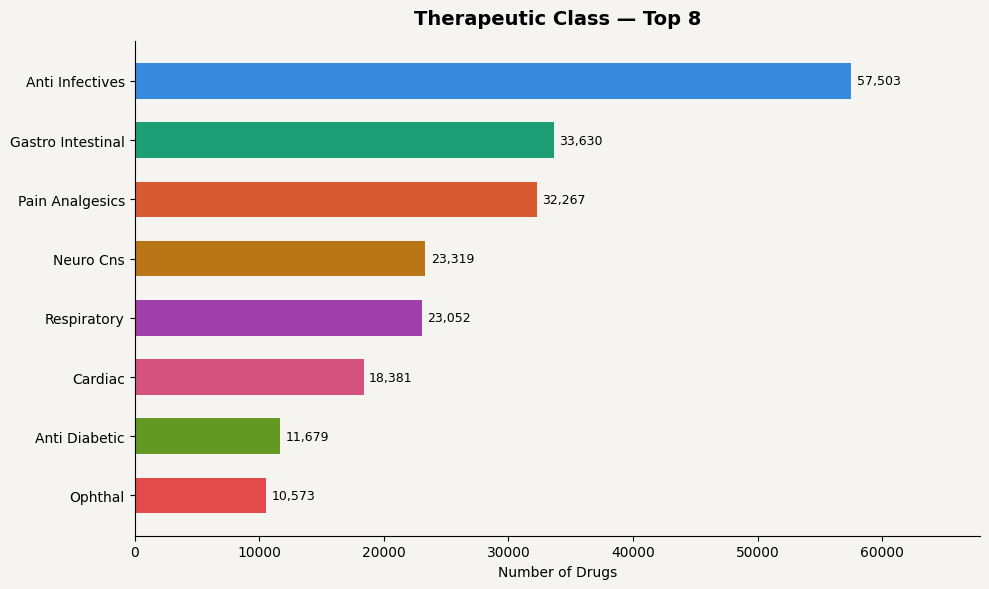

In [95]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F5F4F0')
ax.set_facecolor('#F5F4F0')

colors = ['#378ADD','#1D9E75','#D85A30','#BA7517',
          '#9F3FAA','#D4537E','#639922','#E24B4A']
labels = [x.title() for x in therapeutic.index]
bars   = ax.barh(labels, therapeutic.values, color=colors, height=0.6)

ax.set_title('Therapeutic Class — Top 8', fontsize=14, fontweight='bold', pad=12)
ax.invert_yaxis()
ax.set_xlabel('Number of Drugs')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlim(0, therapeutic.values.max() * 1.18)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_therapeutic.png', dpi=150, bbox_inches='tight')
plt.show()

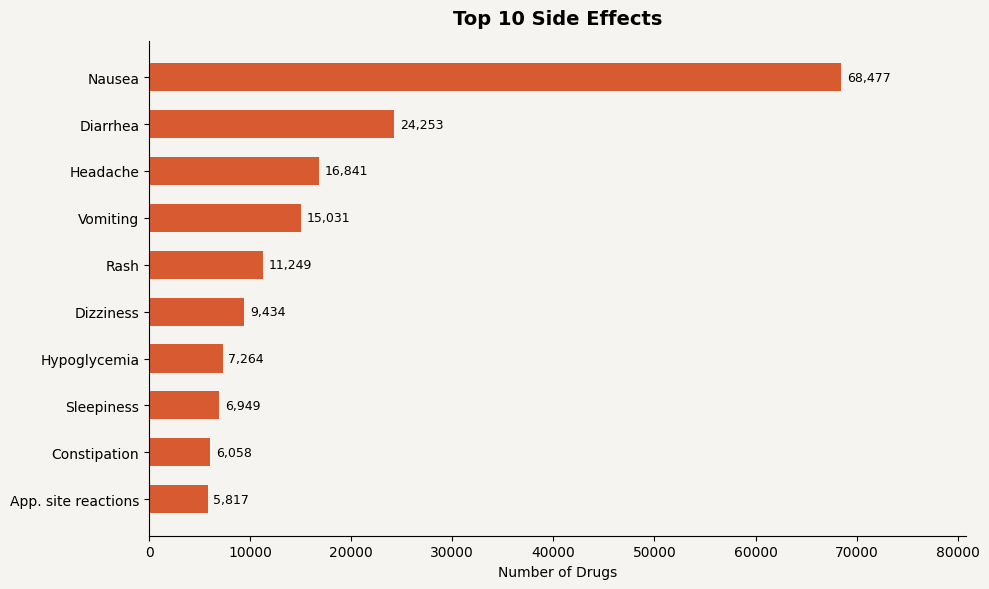

In [96]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F5F4F0')
ax.set_facecolor('#F5F4F0')

short_labels = [
    'Nausea', 'Diarrhea', 'Headache', 'Vomiting', 'Rash',
    'Dizziness', 'Hypoglycemia', 'Sleepiness',
    'Constipation', 'App. site reactions'
]
bars = ax.barh(short_labels, side_effects.values, color='#D85A30', height=0.6)

ax.set_title('Top 10 Side Effects', fontsize=14, fontweight='bold', pad=12)
ax.invert_yaxis()
ax.set_xlabel('Number of Drugs')
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_xlim(0, side_effects.values.max() * 1.18)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_side_effects.png', dpi=150, bbox_inches='tight')
plt.show()

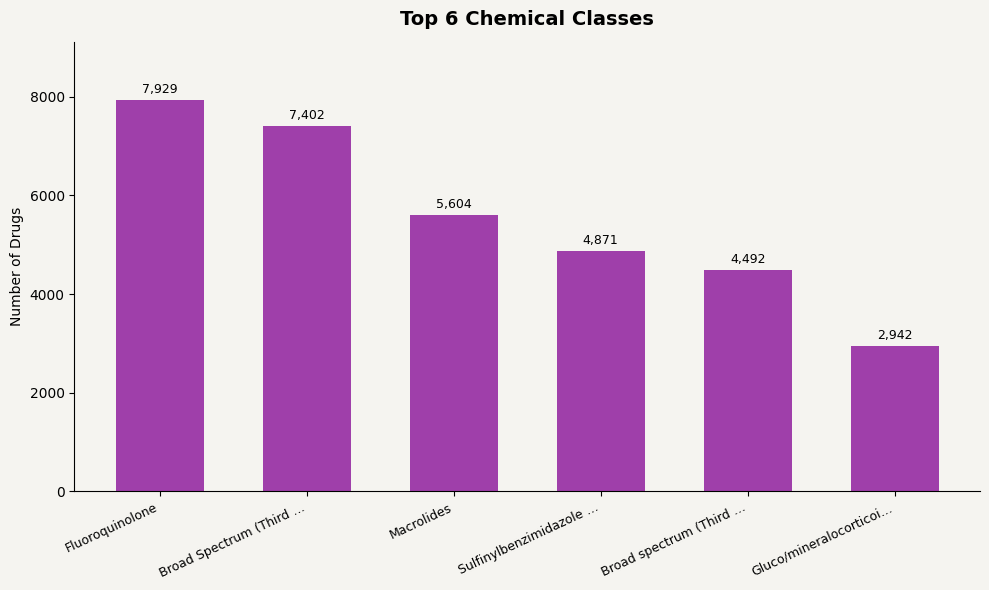

In [98]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F5F4F0')
ax.set_facecolor('#F5F4F0')

short_chem = [x[:22] + '…' if len(x) > 22 else x for x in chemical.index]
bars = ax.bar(range(len(short_chem)), chemical.values, color='#9F3FAA', width=0.6)

ax.set_title('Top 6 Chemical Classes', fontsize=14, fontweight='bold', pad=12)
ax.set_xticks(range(len(short_chem)))
ax.set_xticklabels(short_chem, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Number of Drugs')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.set_ylim(0, chemical.values.max() * 1.15)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart4_chemical.png', dpi=150, bbox_inches='tight')
plt.show()

In [99]:
output_path = r"C:\Users\salma\Documents\collage\datanalytic_sub\medicine_cleaned133.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\nSaved to: {output_path}")


Saved to: C:\Users\salma\Documents\collage\datanalytic_sub\medicine_cleaned133.csv
